In [1]:
import tensorflow_probability as tfp
import tensorflow as tf
from tensorflow.keras import backend as K

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import seaborn as sns
import sys
import os

from importlib import reload

In [2]:
sys.path.insert(0,'../../scripts/tools_for_VAE/')
import tools_for_VAE
from tools_for_VAE import model, boxplot

Using TensorFlow backend.
W1221 12:12:26.261656 140581777033024 deprecation.py:323] From /sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/tensorflow_core/python/compat/v2_compat.py:88: disable_resource_variables (from tensorflow.python.ops.variable_scope) is deprecated and will be removed in a future version.
Instructions for updating:
non-resource variables are not supported in the long term


In [3]:
tf.compat.v1.enable_eager_execution()
tf.executing_eagerly()

True

In [4]:
%matplotlib inline
%config InlineBackend.figure_format='retina'

## Parameters

In [5]:
nb_of_bands = 6
batch_size = 128

input_shape = (59, 59, nb_of_bands)
hidden_dim = 256
latent_dim = 32
final_dim = 1
filters = [32, 64, 128, 256]
kernels = [3,3,3,3]

conv_activation = None
dense_activation = None

bands = [4,5,6,7,8,9]

## Test data

In [6]:
images_dir = '/pbs/home/b/barcelin/sps_link/data/dc2_test/test_mag_24.5/'
img = np.load(images_dir+'img_sample.npy', mmap_mode = 'c')
psf = np.load(images_dir+'psf_sample.npy', mmap_mode = 'c')
data = pd.read_csv(images_dir+'img_data.csv')

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
id                10000 non-null int64
e1                10000 non-null float64
e2                10000 non-null float64
shear_1           10000 non-null float64
shear_2           10000 non-null float64
redshift          10000 non-null float64
redshift_true     10000 non-null float64
blendedness       10000 non-null float64
snr_r             9996 non-null float64
convergence       10000 non-null float64
e1_hsm_regauss    9978 non-null float64
e2_hsm_regauss    9978 non-null float64
mag_r_meas        9996 non-null float64
mag_r_true        10000 non-null float64
dtypes: float64(13), int64(1)
memory usage: 1.1 MB


## Deterministic model

### Loading model

In [7]:
net_det = model.create_model_wo_ls_peak(input_shape, 
                                          latent_dim, 
                                          hidden_dim, 
                                          filters, 
                                          kernels, 
                                          final_dim, 
                                          conv_activation=None, 
                                          dense_activation=None)

W1221 12:12:27.455276 140581777033024 deprecation.py:506] From /sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/tensorflow_core/python/ops/linalg/linear_operator_lower_triangular.py:158: calling LinearOperator.__init__ (from tensorflow.python.ops.linalg.linear_operator) with graph_parents is deprecated and will be removed in a future version.
Instructions for updating:
Do not pass `graph_parents`.  They will  no longer be used.


In [8]:
loading_path = '/sps/lsst/users/barcelin/TFP/weights/test_dc2/v_redshift/loss/'

latest = tf.train.latest_checkpoint(loading_path)
net_det.load_weights(latest)

In [8]:
net_det.summary()

Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 59, 59, 6)]  0                                            
__________________________________________________________________________________________________
batch_normalization (BatchNorma (None, 59, 59, 6)    24          input_1[0][0]                    
__________________________________________________________________________________________________
input_2 (InputLayer)            [(None, 59, 59, 6)]  0                                            
__________________________________________________________________________________________________
conv2d_1 (Conv2D)               (None, 59, 59, 32)   1760        batch_normalization[0][0]        
______________________________________________________________________________________________

### Test on data

In [9]:
N = 2000

img = tf.cast(img[:N], tf.float32)
psf = tf.cast(psf[:N], tf.float32)

In [ ]:
out = net_det([img, psf])

Text(0.5, 1.0, 'redshift reproduction')

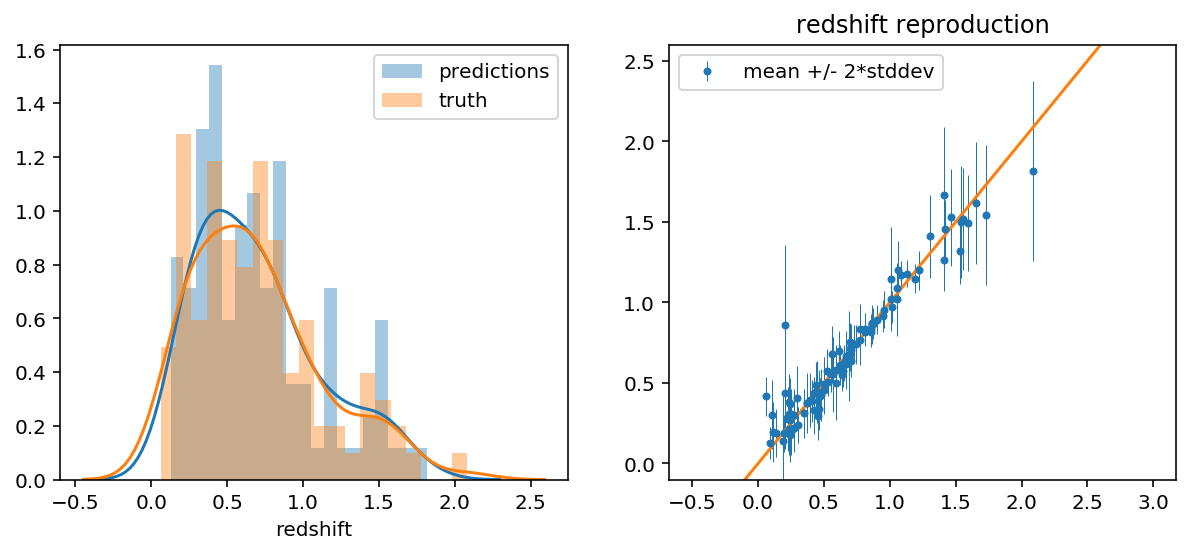

In [11]:
fig, axes = plt.subplots(1,2, figsize=(10,4))
sns.distplot(K.get_value(out.mean())[:,0], bins = 20, label = 'predictions', ax = axes[0])
sns.distplot(data['redshift'][:N], bins = 20, label = 'truth', ax = axes[0])
axes[0].legend()

axes[1].errorbar(data['redshift'][:N], K.get_value(out.mean())[:N,0], yerr = 2*K.get_value(out.stddev())[:N,0],  fmt='.', elinewidth=0.5, label = 'mean +/- 2*stddev')
x = np.linspace(-0.5,3.)
axes[1].plot(x, x)
axes[1].legend()
axes[1].set_ylim(-0.1,2.6)
axes[1].set_title('redshift reproduction')

## Bayesian model (Flipout)

### Loading model

In [ ]:
net_flipout = model.create_model_prob_flipout_peak(input_shape, 
                                          latent_dim, 
                                          hidden_dim, 
                                          filters, 
                                          kernels, 
                                          final_dim, 
                                          conv_activation=None, 
                                          dense_activation=None)

In [ ]:
loading_path = '/sps/lsst/users/barcelin/TFP/weights/test_dc2/v_redshift_flipout/loss/'

latest = tf.train.latest_checkpoint(loading_path)
net_flipout.load_weights(latest)

### Test on data

In [16]:
out_flipout = net_flipout([img, psf])

Text(0.5, 1.0, 'redshift reproduction')

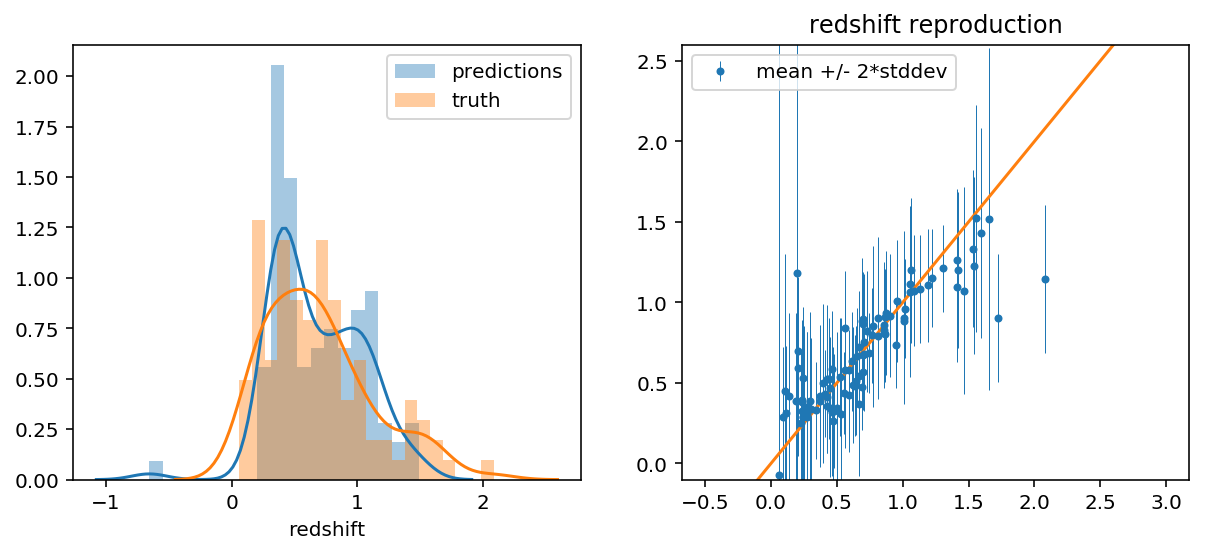

In [17]:
fig, axes = plt.subplots(1,2, figsize=(10,4))
sns.distplot(K.get_value(out_flipout.mean())[:,0], bins = 20, label = 'predictions', ax = axes[0])
sns.distplot(data['redshift'][:N], bins = 20, label = 'truth', ax = axes[0])
axes[0].legend()

axes[1].errorbar(data['redshift'][:N], K.get_value(out_flipout.mean())[:N,0], yerr = 2*K.get_value(out_flipout.stddev())[:N,0],  fmt='.', elinewidth=0.5, label = 'mean +/- 2*stddev')
x = np.linspace(-0.5,3.)
axes[1].plot(x, x)
axes[1].legend()
axes[1].set_ylim(-0.1,2.6)
axes[1].set_title('redshift reproduction')

Swith to order $10^{-2}$ to $10^{-1}$ in MSE occured around epoch 15:

In [ ]:
net_flipout_15 = model.create_model_prob_flipout_peak(input_shape, 
                                          latent_dim, 
                                          hidden_dim, 
                                          filters, 
                                          kernels, 
                                          final_dim, 
                                          conv_activation=None, 
                                          dense_activation=None)

In [ ]:
path = '/sps/lsst/users/barcelin/TFP/weights/test_dc2/v_redshift_flipout/loss/weights_noisy_v4.15-388.23.ckpt'

net_flipout_15.load_weights(path)

In [ ]:
out_flipout_15 = net_flipout_15([img, psf])

fig, axes = plt.subplots(1,2, figsize=(10,4))
sns.distplot(K.get_value(out_flipout_15.mean())[:,0], bins = 20, label = 'predictions', ax = axes[0])
sns.distplot(data['redshift'][:N], bins = 20, label = 'truth', ax = axes[0])
axes[0].legend()

axes[1].errorbar(data['redshift'][:N], K.get_value(out_flipout_15.mean())[:N,0], yerr = 2*K.get_value(out_flipout_15.stddev())[:N,0],  fmt='.', elinewidth=0.5, label = 'mean +/- 2*stddev')
x = np.linspace(-0.5,3.)
axes[1].plot(x, x)
axes[1].legend()
axes[1].set_ylim(-0.5,2.6)
axes[1].set_title('redshift reproduction')

## Compare posteriors after N = 10 samples

### sample 10 times Bayesian networks

In [14]:
out_flipout_mean = []
out_flipout_15_mean =[]
out_flipout_stddev = []
out_flipout_15_stddev =[]

for i in range (5):
    print(i)
    out_flipout_mean.append(net_flipout([img, psf]).mean())
    out_flipout_15_mean.append(net_flipout_15([img, psf]).mean())    
    out_flipout_stddev.append(net_flipout([img, psf]).stddev())
    out_flipout_15_stddev.append(net_flipout_15([img, psf]).stddev())    

0
1
2
3
4


In [15]:
out_flipout_mean = tf.math.reduce_mean(out_flipout_mean, axis=0)
out_flipout_15_mean = tf.math.reduce_mean(out_flipout_15_mean, axis = 0)
out_flipout_stddev = tf.math.reduce_mean(out_flipout_stddev, axis = 0)
out_flipout_15_stddev = tf.math.reduce_mean(out_flipout_15_stddev, axis = 0)

In [ ]:
out_flipout_mean = K.get_value(out_flipout_mean)
#K.clear_session()
#out_flipout_15_mean = K.get_value(out_flipout_15_mean)
#K.clear_session()
#out_flipout_stddev = K.get_value(out_flipout_stddev)
#K.clear_session()
#out_flipout_15_stddev = K.get_value(out_flipout_15_stddev)
#K.clear_session()

In [4]:
tf.executing_eagerly() 

False

In [5]:
a = tf.constant([[1, 2], [3, 4]])                 
b = tf.add(a, 1)

a.numpy()

AttributeError: 'Tensor' object has no attribute 'numpy'

In [19]:
out_flipout_mean.shape

TensorShape([Dimension(2000), Dimension(1)])

In [18]:
x = np.linspace(-1,3, 1000)
def gaussian( mu, sigma):
    x = np.linspace(-1,3, 1000)
    return (1/(sigma*np.sqrt(2*np.pi)))*np.exp(-np.square(x-mu)/(2*sigma**2))

In [ ]:
out_mean = K.get_value(out.mean())[:,0]
out_stddev = K.get_value(out.stddev())[:,0]

fig, axes = plt.subplots(5,2,figsize = (10,20))

for gal in range (5): 
    axes[gal,0].plot(x, gaussian(K.get_value(out_mean[gal]), K.get_value(out_stddev[gal])), label = '$p_{det}(z|x)$')
    axes[gal,0].plot(x, gaussian(K.get_value(out_flipout_mean[gal,0]),K.get_value(out_flipout_stddev[gal,0])), label = '$p_{flipout}(z|x)$')
    axes[gal,0].plot(x, gaussian(K.get_value(out_flipout_15_mean[gal,0]), K.get_value(out_flipout_15_stddev[gal,0])), label = '$p_{flipout_{15}}(z|x)$')
    axes[gal,0].axvline(data['redshift'][gal], color = 'r', label ='true redshift')
    axes[gal,0].legend()
    axes[gal,0].set_xlim(0,2)
    axes[gal,1].imshow(K.get_value(img[gal,:,:,2]))

## Plot redshift bias as function of blending

In [21]:
diff_z_det = data['redshift'][:N] - out_mean
diff_z_flipout = data['redshift'][:N] - out_flipout_mean[:,0]
diff_z_flipout_15 = data['redshift'][:N] - out_flipout_15_mean[:,0]

In [22]:
df_plot = pd.DataFrame()

df_plot['redshift'] = np.concatenate([data['redshift'][:N],data['redshift'][:N], data['redshift'][:N]])
df_plot['blendedness'] = np.concatenate([data['blendedness'][:N],data['blendedness'][:N], data['blendedness'][:N]])
df_plot['redshift_error'] = np.concatenate([diff_z_det,diff_z_flipout,diff_z_flipout_15])
df_plot['exp'] = [1]*N + [2]*N + [3]*N

3000
[1 2 3]
0 1
1 2
2 3


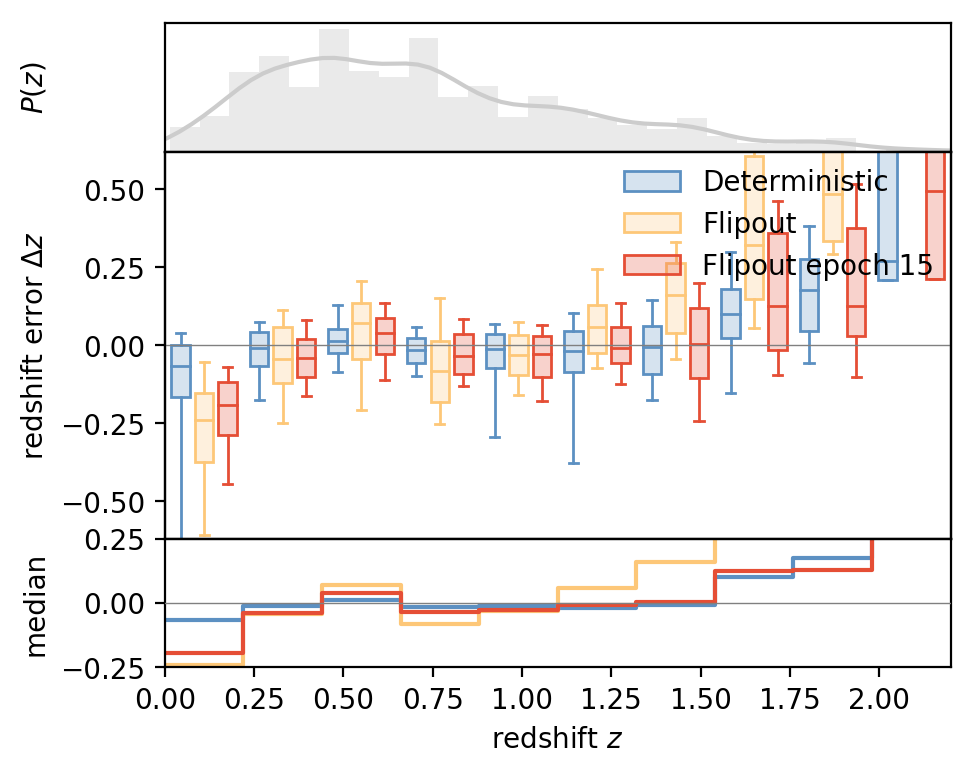

In [23]:
fig, median_shear, q1_shear, q3_shear, whislo_shear, whishi_shear = boxplot.boxplot_func(df_plot, 
              x = 'redshift', y = 'redshift_error', z = 'exp',
              xlim = (0, 2.2),
              ylim = (-0.62, 0.62), 
              ylim2 = (-0.25, 0.25), 
              x_scale = 'linear',
              legend = ['Deterministic', 'Flipout','Flipout epoch 15'],
              x_label='redshift $z$', 
              y_label = 'redshift error $\\Delta z$',
              y_label_hist='$P(z)$',
              y_label_2 = 'median',
              legend_remove = False,
              palette=mpl.cm.RdYlBu([0.85,0.35,0.15]),#0.35,
              nbins = 10)

In [24]:
np.argpartition(df_plot['blendedness'], -9)[-9:]

2991    1814
2992    2814
2993     814
2994     243
2995    1243
2996    2243
2997    2014
2998      14
2999    1014
Name: blendedness, dtype: int64

0.7632253029830287
0.7382407606045791
0.5712619842524903


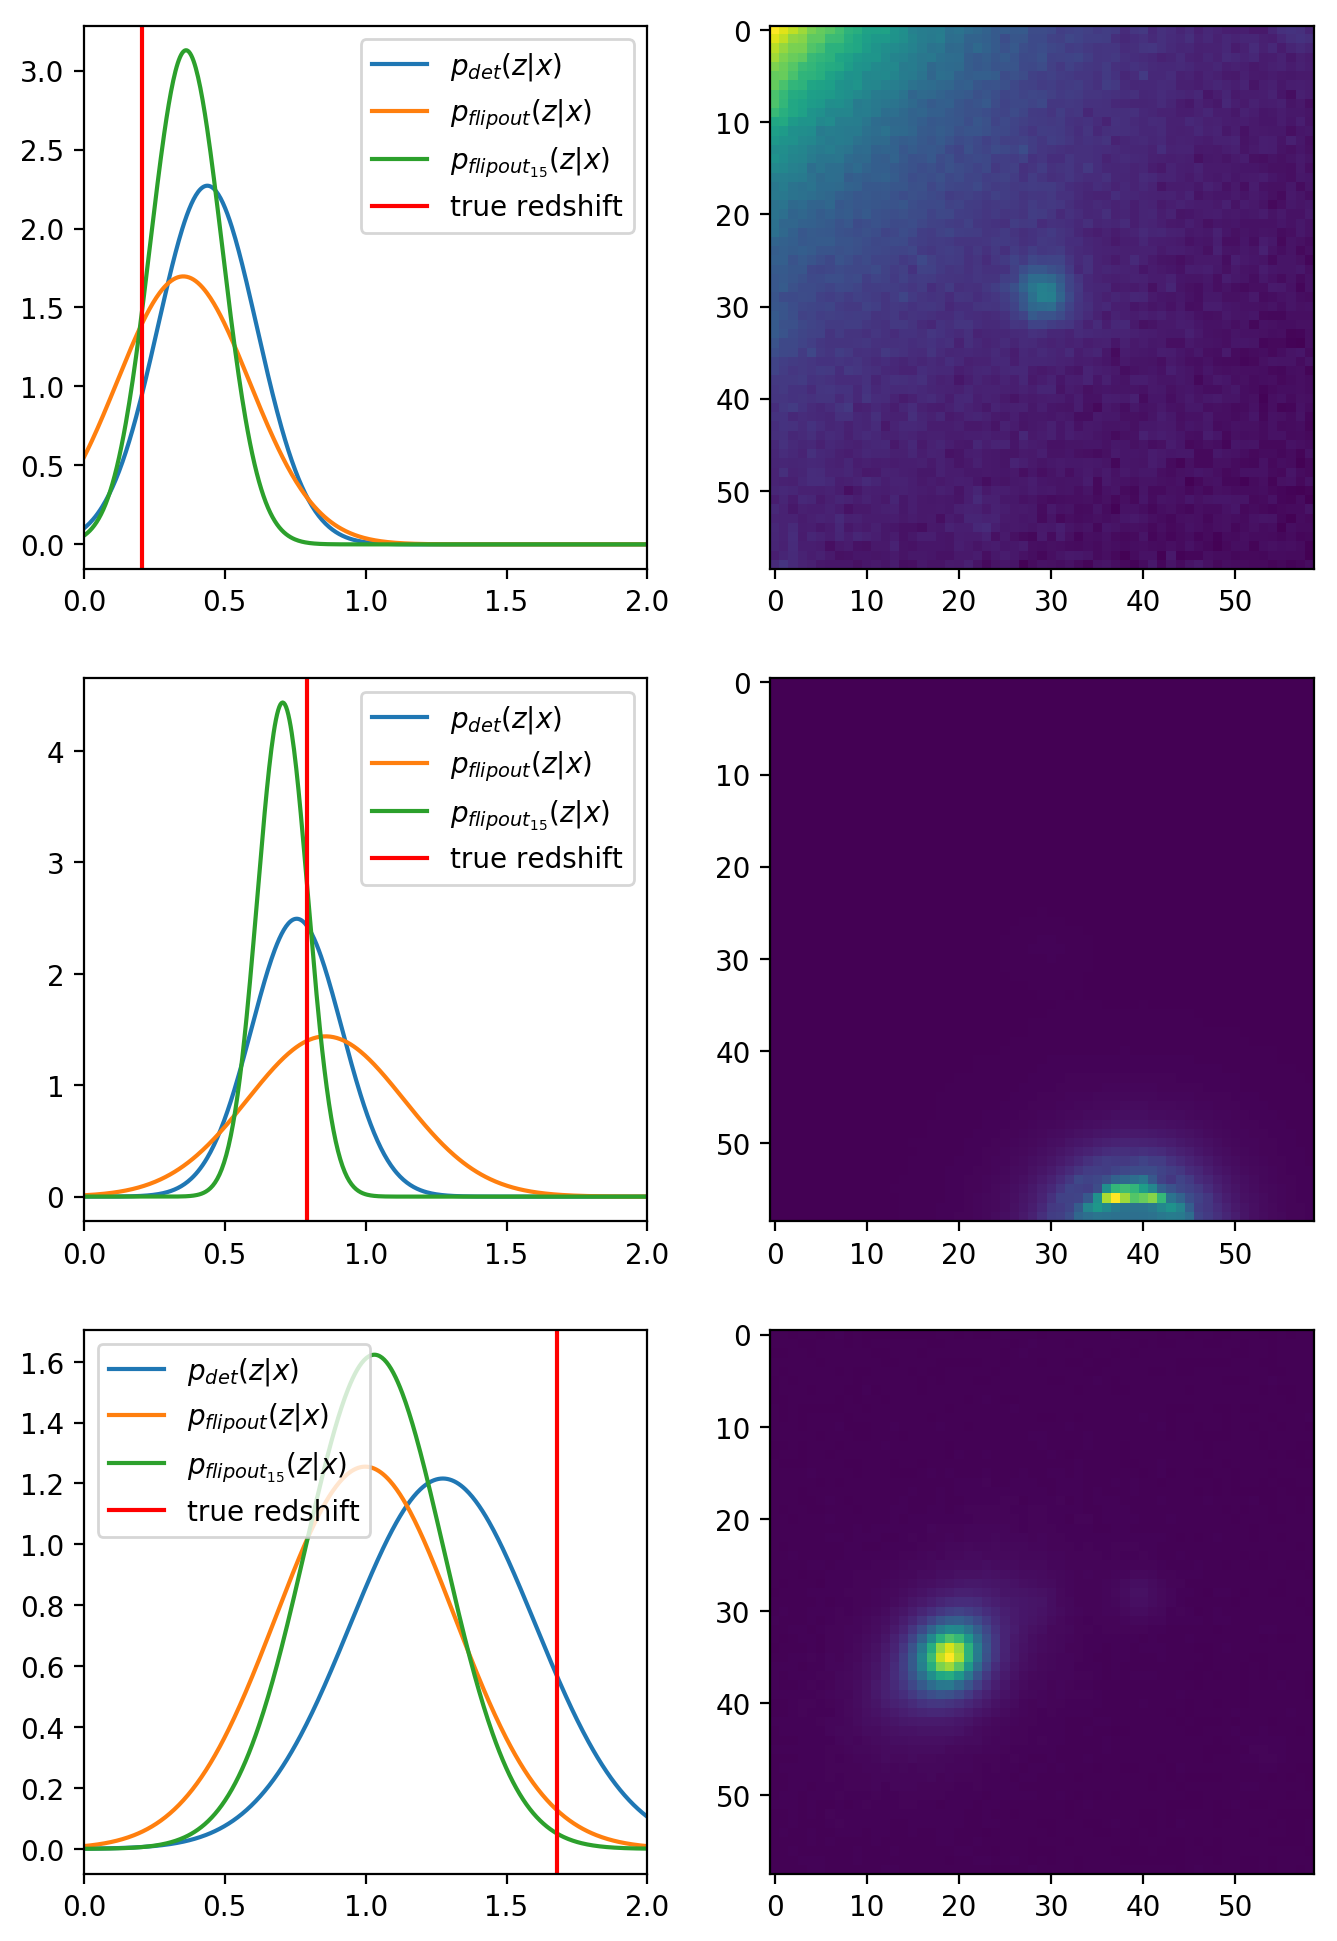

In [33]:
gal_list = [14, 243, 814]

fig, axes = plt.subplots(3,2, figsize = (8,12))
for i, gal in enumerate (gal_list):
    print(df_plot['blendedness'][gal])
    axes[i,0].plot(x, gaussian(out_mean[gal], out_stddev[gal]), label = '$p_{det}(z|x)$')
    axes[i,0].plot(x, gaussian(out_flipout_mean[gal,0],out_flipout_stddev[gal,0]), label = '$p_{flipout}(z|x)$')
    axes[i,0].plot(x, gaussian(out_flipout_15_mean[gal,0], out_flipout_15_stddev[gal,0]), label = '$p_{flipout_{15}}(z|x)$')
    axes[i,0].axvline(data['redshift'][gal], color = 'r', label ='true redshift')
    axes[i,0].legend()
    axes[i,0].set_xlim(0,2)
    axes[i,1].imshow(K.get_value(img[gal,:,:,2]))

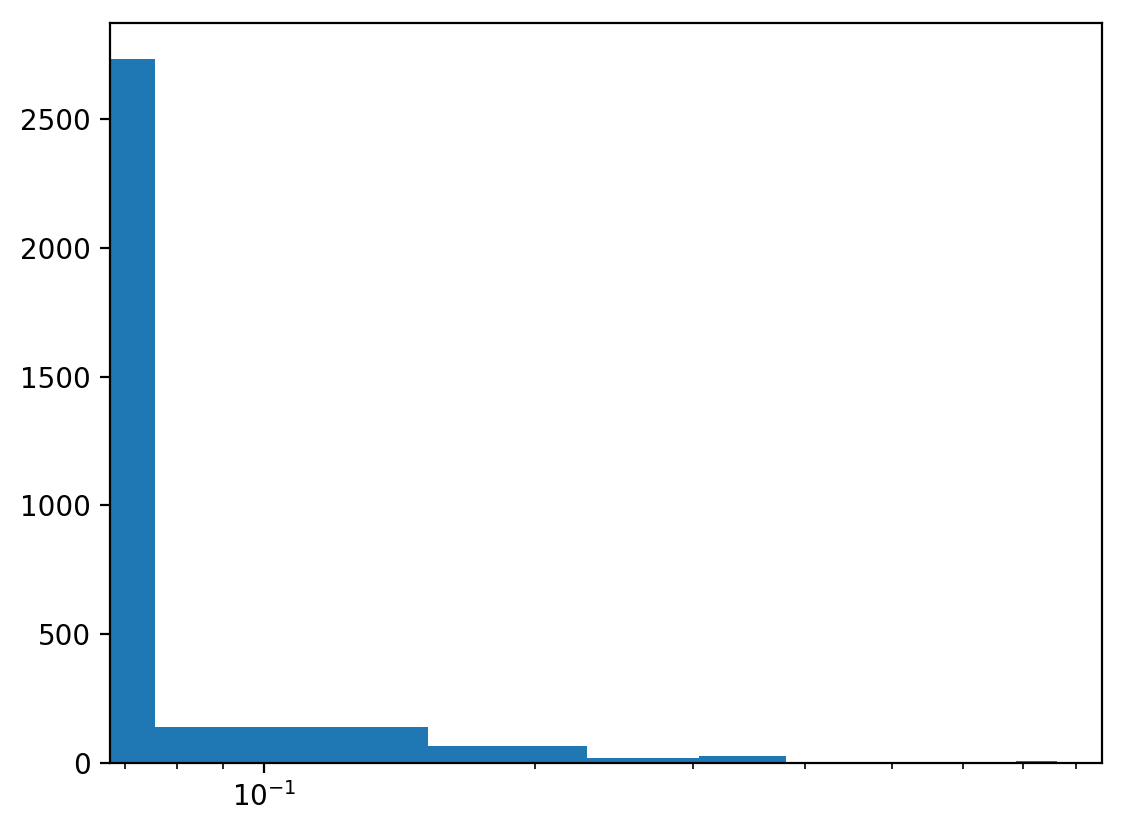

In [28]:
_ = plt.hist(df_plot['blendedness'], bins = 10)
plt.xscale('log')

3000
[1 2 3]
0 1
1 2
2 3


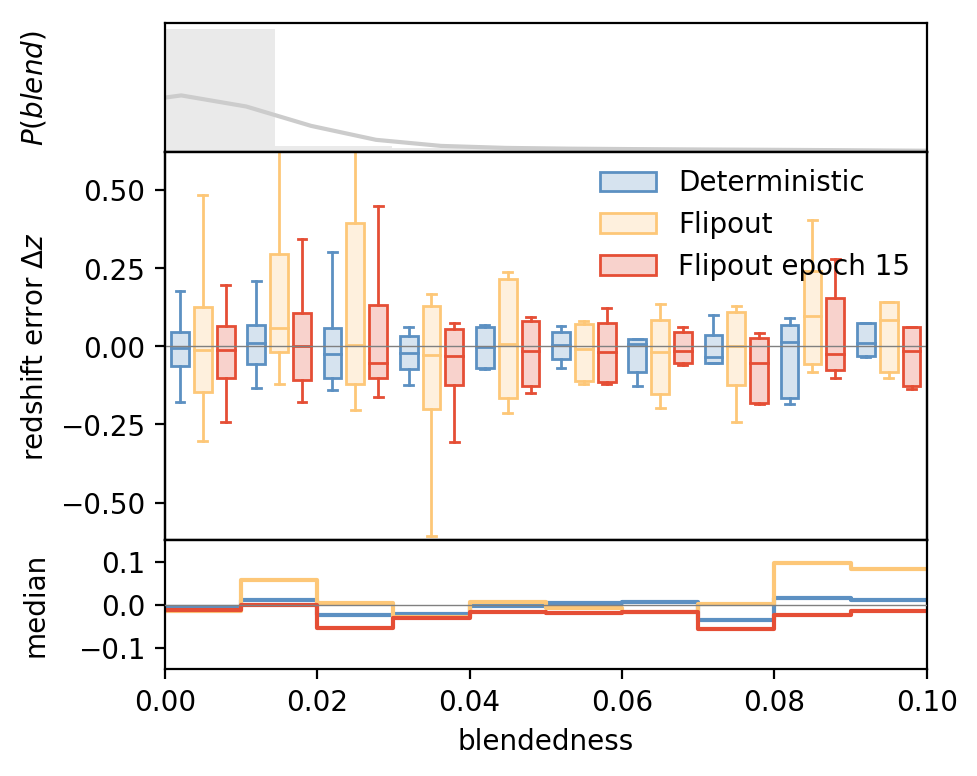

In [36]:
fig, median_shear, q1_shear, q3_shear, whislo_shear, whishi_shear = boxplot.boxplot_func(df_plot, 
              x = 'blendedness', y = 'redshift_error', z = 'exp',
              xlim = (0, 0.1),
              ylim = (-0.62, 0.62), 
              ylim2 = (-0.15, 0.15), 
              x_scale = 'linear',
              legend = ['Deterministic', 'Flipout','Flipout epoch 15'],
              x_label='blendedness', 
              y_label = 'redshift error $\\Delta z$',
              y_label_hist='$P(blend)$',
              y_label_2 = 'median',
              legend_remove = False,
              palette=mpl.cm.RdYlBu([0.85,0.35,0.15]),
              nbins = 10)